In [165]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
data = pd.read_excel("heartrate.xlsx")
data.head()

,ID,年龄,ET天,孕囊,胚芽,卵黄囊,胎心,标签
0,1,29,33,15X10,6,5.6,119.0,0
1,2,28,36,35X20,9.5,4.3,120.0,0
2,3,26,30,17X12,3,4.5,110.0,0
3,4,26,29,17X13,5.3,4.5,94.0,0
4,5,29,29,14X8,2.7,4.2,88.0,0


In [166]:
print(data.shape)
data.isnull().any()
#这个表明是没有空缺值的

(11125, 8)


ID     False
年龄     False
ET天    False
孕囊     False
胚芽     False
卵黄囊    False
胎心     False
标签     False
dtype: bool

ok，接下来对数据进行处理，主要是以下步骤  
1.把ID列给删了  
2.把孕囊列拆成三列  
3.暂时还不知道标签列干嘛的，先留着  
4.数据集标准化处理  
5.进行相关性分析  
6.选取特征值  

In [167]:
data_heart=data.drop('ID',axis=1)
data_heart['孕囊'] = data_heart['孕囊'].str.replace('x','X').str.replace('×','X')
data_heart[['length','width']] = data_heart['孕囊'].str.split('X', expand=True)
# 转换成数值类型
data_heart[['length','width']] = data_heart[['length','width']].apply(pd.to_numeric, errors='coerce')
# 具体操作取决于实际情况，以下为删除含有 NaN 值的行
data_heart=data_heart.dropna(subset=['length', 'width'])
# 计算面积
data_heart['area'] = data_heart['length'] *data_heart['width']
print(data_heart.shape)
data_heart.isnull().any()
data_heart=data_heart.drop('孕囊',axis=1)

features_label=['年龄','ET天','length','width','area','胚芽','卵黄囊','胎心']

# 对特征进行标准化处理
# 尝试转化为数字，出错则替换为NaN
data_heart[features_label] = data_heart[features_label].apply(lambda x: pd.to_numeric(x, errors='coerce'))
#使用0填充NaN
#data_heart[features_label] = data_heart[features_label].fillna(0)

#使用均值填充NaN，需要指定axis=0来表示对列进行操作
data_heart[features_label] = data_heart[features_label].fillna(data_heart[features_label].mean(axis=0))  

data_heart.rename(columns={
    '年龄': 'age',
    'ET天': 'ET',
    '胚芽': 'embryo',
    '卵黄囊': 'yolk_sac',
    '胎心': 'heart_rate',
    '标签': 'label',
}, inplace=True)
#分割数据集，用train_test_split
print(data_heart.head())

(11001, 10)
   age  ET  embryo  yolk_sac  heart_rate  label  length  width   area
0   29  33     6.0       5.6       119.0      0    15.0   10.0  150.0
1   28  36     9.5       4.3       120.0      0    35.0   20.0  700.0
2   26  30     3.0       4.5       110.0      0    17.0   12.0  204.0
3   26  29     5.3       4.5        94.0      0    17.0   13.0  221.0
4   29  29     2.7       4.2        88.0      0    14.0    8.0  112.0


In [168]:
heartrate_corr=abs(data_heart.corr())
heartrate_corr=heartrate_corr.round(2)
print(heartrate_corr.head(9))


             age    ET  embryo  yolk_sac  heart_rate  label  length  width  \
age         1.00  0.00    0.05      0.04        0.14   0.19    0.06   0.04   
ET          0.00  1.00    0.92      0.48        0.52   0.26    0.80   0.78   
embryo      0.05  0.92    1.00      0.57        0.71   0.46    0.87   0.83   
yolk_sac    0.04  0.48    0.57      1.00        0.64   0.52    0.60   0.55   
heart_rate  0.14  0.52    0.71      0.64        1.00   0.86    0.72   0.63   
label       0.19  0.26    0.46      0.52        0.86   1.00    0.53   0.43   
length      0.06  0.80    0.87      0.60        0.72   0.53    1.00   0.82   
width       0.04  0.78    0.83      0.55        0.63   0.43    0.82   1.00   
area        0.03  0.85    0.90      0.52        0.61   0.40    0.91   0.94   

            area  
age         0.03  
ET          0.85  
embryo      0.90  
yolk_sac    0.52  
heart_rate  0.61  
label       0.40  
length      0.91  
width       0.94  
area        1.00  


In [169]:
if (data_heart['heart_rate'] == 0).any():
    print("The column 'heart_rate' contains zero.")
else:
    print("The column 'heart_rate' does not contain zero.")

The column 'heart_rate' contains zero.


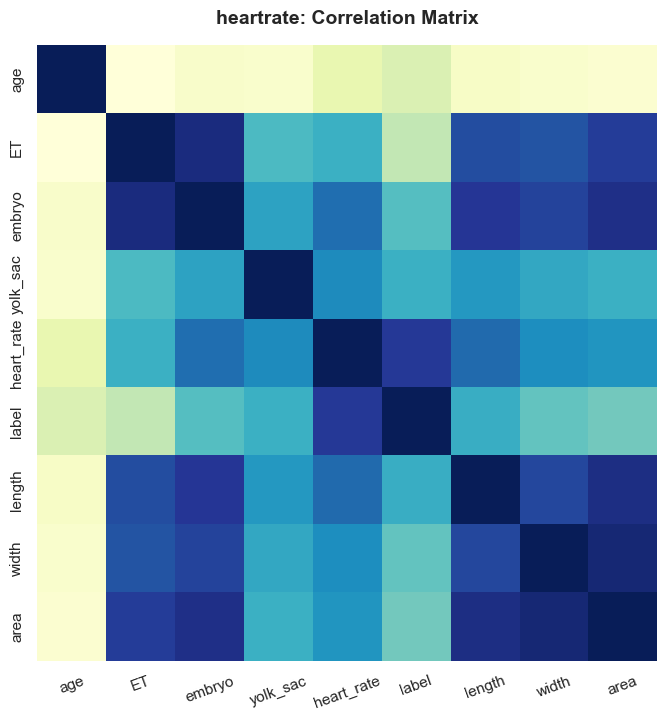

In [186]:
import seaborn as sns
sns.set(rc={'figure.figsize':(8,8)})
# Visually display the matrix from above
# use the yellow-green-blue color map so that high correlations are more easily identifiable
h = sns.heatmap(heartrate_corr, annot=False, cmap="YlGnBu", cbar=False)
# Add plot title
h.set_title('heartrate: Correlation Matrix', size=14, weight='bold', pad=15)
# rotate tick marks so they are easier to read
plt.xticks(rotation=20)
# Display plot
plt.show()

In [171]:
data_heart.isnull().any()
#这个表明是没有空缺值的

age           False
ET            False
embryo        False
yolk_sac      False
heart_rate    False
label         False
length        False
width         False
area          False
dtype: bool

# pytorch

In [11]:
import torch
import torch.nn as nn

#提取特征以及标签列表
label_df=data_heart.iloc[:,4]
features_df=data_heart.drop('heart_rate',axis=1)
#分割数据集
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(features_df.values, label_df.values, test_size=0.3, random_state=0)

#scaler()
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler_y=StandardScaler()
#对训练集的数据进行fit
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train=scaler_y.fit_transform(y_train.reshape(-1,1))
y_test=scaler_y.transform(y_test.reshape(-1,1))
#接下来转换成torch dataloader对象


from torch.utils.data import TensorDataset, DataLoader
# Convert the datasets to PyTorch tensors
train_features = torch.tensor(X_train, dtype=torch.float32)
test_features = torch.tensor(X_test, dtype=torch.float32)

train_labels = torch.tensor(y_train, dtype=torch.float)
test_labels = torch.tensor(y_test, dtype=torch.float)

train_dataset = TensorDataset(train_features, train_labels)
test_dataset = TensorDataset(test_features, test_labels)

# Set up data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [13]:
hidden_size1 = 150
hidden_size2 = 120

# 定义神经网络结构
class Net(nn.Module):
    def __init__(self,activation='relu'):
        super(Net, self).__init__()
        self.activation=activation
        # 输入层到隐藏层，8个特征输入，hidden_size1个输出
        self.fc1 = nn.Linear(8, hidden_size1)
        # 隐藏层到隐藏层，hidden_size1个输入，hidden_size2个输出
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        # 隐藏层到输出层，hidden_size2个输入，1个输出（预测的年龄）
        self.fc3 = nn.Linear(hidden_size2, 1)

    def forward(self, x):
        if self.activation=='relu':
            # 使用ReLU激活函数
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
            return x
        elif self.activation=='sigmoid':
            x = torch.sigmoid(self.fc1(x))
            x = torch.sigmoid(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
            return x
#定义训练损失函数
#转移到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net=Net()
net.to(device)
initial_lr=0.02
loss_fn=nn.MSELoss()
batch_size=32
optimizer = torch.optim.SGD(net.parameters(), lr=initial_lr)
# 列出网络中所有的可以优化的参数
# for name, param in net.named_parameters():
#     if param.requires_grad:
#         print(name, param.data)
num_epochs=200

#定义验证损失函数
def validate(model, criterion, val_loader):
    model.eval()  # 设置模型为评估模式
    total_val_loss = 0
    with torch.no_grad():  # 不需要计算梯度，也不会进行反向传播
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # 如果使用 GPU，将数据移到 GPU
            outputs = model(inputs)  # 前向传播计算模型的预测值
            loss = criterion(outputs, targets.reshape(-1,1))  # 计算损失
            total_val_loss += loss.item()  # 累计损失

    average_val_loss = total_val_loss / len(val_loader)  # 计算平均损失
    return average_val_loss
def validate_and_calculate_MAE(model, val_loader):
    model.eval()
    total_val_loss = 0
    total_abs_error = 0
    count = 0   # 计算总的样本数，用于最后的平均
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            abs_error = torch.abs(outputs - targets.reshape(-1,1)) # 计算 |预测-实际|
            total_abs_error += torch.sum(abs_error).item() # 累加
            count += inputs.size(0) # 累加样本数
    average_MAE = total_abs_error / count # 最终的 MAE
    return average_MAE
# 定义一个简单的函数来调整学习率
def adjust_learning_rate(optimizer, epoch, initial_lr):
    """Sets the learning rate to the initial LR decayed by 2 every 50 epochs after the first 100"""
    if epoch <= 100:
        lr = initial_lr
    else:
        lr = initial_lr * (0.5 ** ((epoch - 100) // 50))   # // 表示整数除法
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

#---------------------------------------------------------Start Training--------------------------------------------
#record parrameters
best_val_loss_mae=float("inf")
best_model_parameter=[0,0]
train_losses = []
from torch.optim import lr_scheduler
# 初始化 optimizer
#optimizer = torch.optim.SGD(net.parameters(), lr=0.02, momentum=0.9)

# 设置 scheduler
#scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
valid_losses=[]
#MSE
for epoch in range(num_epochs):
    epoch_loss = 0
    
    for i, (inputs, targets) in enumerate(train_loader):
        adjust_learning_rate(optimizer, epoch, initial_lr)
        # clear previous gradients
        optimizer.zero_grad()
        # forward pass
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = net(inputs)
        # calculate loss
        loss = loss_fn(outputs, targets.reshape(-1,1))
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()   
        # 累积每一个批次的训练损失
        epoch_loss += loss.item()
        #验证过程——MAE
        val_loss_MAE=validate_and_calculate_MAE(net,test_loader)
        val_loss_MSE=validate(net,loss_fn,test_loader)
        if best_val_loss_mae<val_loss_MAE:
            best_val_loss_mae=val_loss_MAE
            torch.save(net.state_dict(), "best_model_checkpoint.pth")
            best_model_parameter=[val_loss_MSE,val_loss_MAE]
        # 如果验证损失在一段时间内没有下降，scheduler 会减少 learning rate
        #scheduler.step(val_loss)
    # 每一个epoch结束后，计算平均损失并记录
    epoch_loss /= len(train_loader) 
    print('Epoch [{}/{}], train_Loss_MSE: {:.4f},val_Loss_MSE: {:.4f},val_loss_MAE:{:.4f}'.format(epoch+1, num_epochs, epoch_loss,val_loss_MSE,val_loss_MAE))
    train_losses.append(epoch_loss)
    valid_losses.append(val_loss_MSE)
print("best_model_parameter:")
print("val_loss_MSE:",best_model_parameter[0])
print("val_loss_MAE:",best_model_parameter[1])

Epoch [1/200], train_Loss_MSE: 0.1551,val_Loss_MSE: 0.1162,val_loss_MAE:0.2008
Epoch [2/200], train_Loss_MSE: 0.0977,val_Loss_MSE: 0.1028,val_loss_MAE:0.1968
Epoch [3/200], train_Loss_MSE: 0.0894,val_Loss_MSE: 0.0956,val_loss_MAE:0.1768
Epoch [4/200], train_Loss_MSE: 0.0835,val_Loss_MSE: 0.0902,val_loss_MAE:0.1715
Epoch [5/200], train_Loss_MSE: 0.0786,val_Loss_MSE: 0.0821,val_loss_MAE:0.1685
Epoch [6/200], train_Loss_MSE: 0.0742,val_Loss_MSE: 0.0826,val_loss_MAE:0.1696
Epoch [7/200], train_Loss_MSE: 0.0697,val_Loss_MSE: 0.0708,val_loss_MAE:0.1612
Epoch [8/200], train_Loss_MSE: 0.0661,val_Loss_MSE: 0.0674,val_loss_MAE:0.1528
Epoch [9/200], train_Loss_MSE: 0.0622,val_Loss_MSE: 0.0661,val_loss_MAE:0.1493
Epoch [10/200], train_Loss_MSE: 0.0590,val_Loss_MSE: 0.0578,val_loss_MAE:0.1478
Epoch [11/200], train_Loss_MSE: 0.0562,val_Loss_MSE: 0.0559,val_loss_MAE:0.1389
Epoch [12/200], train_Loss_MSE: 0.0529,val_Loss_MSE: 0.0502,val_loss_MAE:0.1365
Epoch [13/200], train_Loss_MSE: 0.0504,val_Loss_M

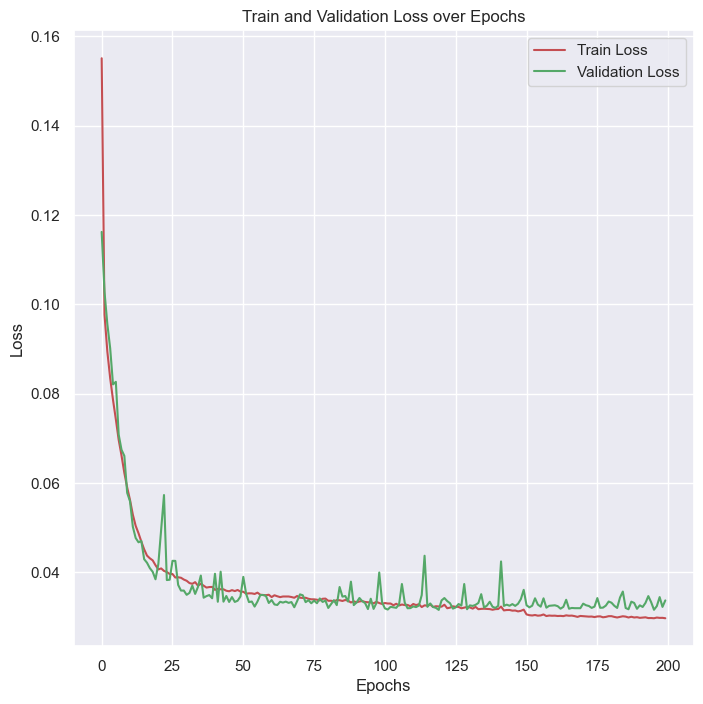

In [19]:
#实际误差是61。8*0.1017=6.69
#01062,0.1020
plt.figure()
plt.plot(train_losses, 'r', label='Train Loss')
plt.plot(valid_losses, 'g', label='Validation Loss')
plt.title('Train and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#定义一个计算R^2的函数
#TSS = ∑(yi - y_mean)²，RSS = ∑(yi - ŷi)²
#rsquared=1-rss/tss
def rsquared(y_train,y_pred):
    rss=sum((y_train-y_pred)**2)
    tss=sum((y_train-np.mean(y_train))**2)
    rsquared=1-rss/tss
    return rsquared



In [21]:
# 获取标签列的索引，我假设它是最后一列
# 获取 "胎心" 所在的索引

def model_predict(model, predict_data,min_mae):
    model.eval()
    sum=0
    count=0
    with torch.no_grad():
        for features, label in predict_data:
            features = features.to(device)
            label = label.to(device)
            predict_rate_untransformed=model(features)
            # 获取相应的均值和标准差
            label_mean = scaler_y.mean_
            label_std = scaler_y.scale_
            # 反向变换
            # 反向变换
            predict_rate= (predict_rate_untransformed.cpu().numpy()*label_std) + label_mean
            label_transformed = (label.cpu().numpy()*label_std) + label_mean
            #计算一下差值平均
            aver_error=min_mae*label_std
            R2=rsquared(label_transformed,predict_rate)
    #print(predict_rate,label_transformed)
    print('label_mean:',label_mean,'label_std:',label_std)
    print('aver_error(transformed):',aver_error)
    print('R^2:',R2)


#加载最好的checkpoint
best_model = Net()
best_model.load_state_dict(torch.load("best_model_checkpoint.pth"))
model_predict(net,test_loader,best_val_loss_mae)

label_mean: [104.4928961] label_std: [61.86305437]
aver_error(transformed): [6.31003155]
R^2: [0.9660917]


# mindspore

In [172]:
#提取特征以及标签列表
label_df=data_heart.iloc[:,4]
features_df=data_heart.drop('heart_rate',axis=1)
#分割数据集
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(features_df.values, label_df.values, test_size=0.3, random_state=0)

#scaler()
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler_y=StandardScaler()
#对训练集的数据进行fit
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train=scaler_y.fit_transform(y_train.reshape(-1,1))
y_test=scaler_y.transform(y_test.reshape(-1,1))
#接下来转换

import mindspore.dataset as ds
from mindspore import Tensor
import numpy as np

# MindSpore不直接使用Numpy数组创建数据集，需要先将他们转换为Tensor。
train_features = Tensor(X_train, mstype.float32)
test_features = Tensor(X_test, mstype.float32)

train_labels = Tensor(y_train.reshape(-1, 1), mstype.float32)
test_labels = Tensor(y_test.reshape(-1, 1), mstype.float32)

# 创建MindSpore格式的数据集
train_data = ds.NumpySlicesDataset({'features': train_features.asnumpy(), 'labels': train_labels.asnumpy()}, shuffle=True)
test_data = ds.NumpySlicesDataset({'features': test_features.asnumpy(), 'labels': test_labels.asnumpy()})

# 设置批处理大小
batch_size = 32
train_data = train_data.batch(batch_size)
test_data = test_data.batch(len(test_labels))

# 如果你需要迭代数据集，可以用以下代码块来代替PyTorch的DataLoader
# 因为创建的train_data和test_data可以直接迭代
for data in train_data.create_dict_iterator(): 
    features, labels = data['features'], data['labels']


hidden_size1 = 150
hidden_size2 = 120
import mindspore.nn as nn
from mindspore.common.initializer import Normal

class Net(nn.Cell):
    def __init__(self, input_size, hidden_size1, hidden_size2, activation='relu'):
        super(Net, self).__init__()
        self.activation = activation
        # 输入层到隐藏层，input_size个特征输入，hidden_size1个输出
        self.fc1 = nn.Dense(input_size, hidden_size1, weight_init=Normal(0.02), bias_init=Normal(0.02))
        # 隐藏层到隐藏层，hidden_size1个输入，hidden_size2个输出
        self.fc2 = nn.Dense(hidden_size1, hidden_size2, weight_init=Normal(0.02), bias_init=Normal(0.02))
        # 隐藏层到输出层，hidden_size2个输入，1个输出（预测值）
        self.fc3 = nn.Dense(hidden_size2, 1, weight_init=Normal(0.02), bias_init=Normal(0.02))

    def construct(self, x):
        if self.activation == 'relu':
            # 使用ReLU激活函数
            x = nn.ReLU()(self.fc1(x))
            x = nn.ReLU()(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
        elif self.activation == 'sigmoid':
            x = nn.Sigmoid()(self.fc1(x))
            x = nn.Sigmoid()(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
        return x

# 实例化网络，设定输入特征大小为8
net = Net(input_size=8, hidden_size1=150, hidden_size2=120, activation='relu')

In [173]:
from mindspore import nn, context
from mindspore.train.callback import Callback
from mindspore import ops

# 设置为CPU训练模式
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
initial_lr = 0.02
# 使用均方误差作为损失函数
loss_fn = nn.MSELoss()
batch_size = 32
optimizer = nn.SGD(net.trainable_params(), learning_rate=initial_lr,momentum=0.9)
num_epochs = 200

# 定义验证损失函数
# def validate(model, criterion, val_loader):
#     total_val_loss = 0
#     for data in val_loader.create_dict_iterator(output_numpy=True):
#         inputs, targets = data["features"], data["labels"]
#         outputs = model(inputs)
#         loss = criterion(ops.reshape(outputs, (-1, 1)), ops.reshape(targets, (-1, 1)))
#         total_val_loss += loss.asnumpy().item()
    
#     average_val_loss = total_val_loss / val_loader.get_dataset_size()
#     return average_val_loss

# # 定义计算平均绝对误差（MAE）的函数
# def validate_and_calculate_MAE(model, val_loader):
#     total_abs_error = 0
#     count = 0  # 计算总的样本数，用于最后的平均
#     for data in val_loader.create_dict_iterator(output_numpy=True):
#         inputs, targets = data["features"], data["labels"]
#         outputs = model(inputs)
#         abs_error = ops.abs(ops.reshape(outputs, (-1, 1)) - ops.reshape(targets, (-1, 1)))
#         total_abs_error += abs_error.asnumpy().sum()
#         count += inputs.shape[0]

#     average_MAE = total_abs_error / count
#     return average_MAE
import mindspore.numpy as mnp

def calc_mae(model, val_loader):
    total_abs_error = 0
    total_samples = 0
    for data in val_loader.create_dict_iterator(output_numpy=True):
        inputs, targets = Tensor(data["features"]), Tensor(data["labels"])
        # 直接使用模型进行预测
        outputs = model.predict(inputs)
        abs_error = np.abs(outputs.asnumpy() - targets)
        total_abs_error += abs_error.sum()
        total_samples += inputs.shape[0]
    
    average_mae = total_abs_error / total_samples
    return average_mae
# 定义回调函数用于在每个epoch后计算测试集损失

import os
class ValLossMonitor(Callback):
    def __init__(self, model,net,val_data, val_loss_list, best_checkpoint_path):
        super(ValLossMonitor, self).__init__()
        self.model=model
        self.net = net
        self.val_data = val_data
        self.val_loss_list = val_loss_list
        self.best_mae = float('inf')
        self.best_checkpoint_path = best_checkpoint_path

    def on_train_epoch_end(self, run_context):
        cb_params = run_context.original_args()
        # 计算验证集上的损失（例如MSE）
        val_loss_mse = self.model.eval(self.val_data, dataset_sink_mode=False)
        self.val_loss_list.append(val_loss_mse)
        # 假设你有一个函数 calc_mae 来计算MAE损失
        val_loss_mae = calc_mae(self.model, self.val_data)

        # 打印当前epoch的验证损失
        print(f'Val Loss MSE :{val_loss_mse}, Val Loss MAE = {val_loss_mae}')

        # 如果当前MAE比记录的最佳MAE小，更新最佳MAE并保存checkpoint
        if val_loss_mae < self.best_mae:
            self.best_mae = val_loss_mae
            # 保存或更新checkpoint
            print(f'New best MAE: {self.best_mae}. Saving checkpoint.')
            save_checkpoint(self.net, self.best_checkpoint_path)

class CustomLossMonitor(Callback):
    def __init__(self, train_loss_list):
        super(CustomLossMonitor, self).__init__()
        self.train_loss_list = train_loss_list

    def on_train_epoch_end(self, run_context):
        cb_params = run_context.original_args()
        train_loss = cb_params.net_outputs
        self.train_loss_list.append(train_loss)
        print(f"Epoch {cb_params.cur_epoch_num} Train Loss: {train_loss}")
        
from mindspore.nn.learning_rate_schedule import LearningRateSchedule

class MyLRSchedule(LearningRateSchedule):
    def __init__(self, initial_lr, total_steps):
        super(MyLRSchedule, self).__init__()
        self.initial_lr = initial_lr
        self.total_steps = total_steps

    def get_lr(self, current_step):
        # MindSpore 自动管理并传递 current_step，你无需手动获取
        if current_step <= 100:
            lr = self.initial_lr
        else:
            lr = self.initial_lr * (0.5 ** ((current_step - 100) // 50))
        return lr
def create_dataset(train_features, train_labels, batch_size, shuffle=True):
    # 此函数用于创建新的数据集实例
    return ds.NumpySlicesDataset({'features': train_features.asnumpy(), 'labels': train_labels.asnumpy()}, shuffle=shuffle).batch(batch_size)

In [174]:
from mindspore import Model
from mindspore.train.callback import LossMonitor, ModelCheckpoint, CheckpointConfig
from mindspore.train.serialization import load_checkpoint, save_checkpoint
loss_fn = nn.MSELoss()
#lr_schedule = MyLRSchedule(initial_lr, total_epochs)
from mindspore.train.metrics import Metric
# 定义MSE Metric
class MSEMetric(Metric):
    def __init__(self):
        super(MSEMetric, self).__init__()
        self.clear()

    def clear(self):
        self.total_loss = 0
        self.samples = 0

    def update(self, *inputs):
        if len(inputs) != 2:
            raise ValueError('MSEMetric needs 2 inputs (y_pred, y), but got {}'.format(len(inputs)))
        y_pred, y = inputs
        loss = np.mean((y_pred.asnumpy() - y.asnumpy()) ** 2)
        self.total_loss += loss
        self.samples += 1

    def eval(self):
        if self.samples == 0:
            raise RuntimeError("Samples cannot be 0.")
        return self.total_loss / self.samples

#optimizer = nn.SGD(net.trainable_params(), learning_rate=initial_lr)
# 实例化模型
model = Model(net, loss_fn=loss_fn, optimizer=optimizer,metrics={"MSE": MSEMetric()})

# 设置模型保存的配置
#config_ck = CheckpointConfig(save_checkpoint_steps=1, keep_checkpoint_max=1)
#ckpoint_cb = ModelCheckpoint(prefix="checkpoint_net", directory='./', config=config_ck)
best_checkpoint_path='best_checkpoint'
# 记录最佳验证损失和模型参数
best_val_loss_mae = float('inf')
train_losses = []
valid_losses = []

#for epoch in range(1,num_epochs+1):
#epoch_loss = 0
    
# 使用自定义学习率调整回调函数
# adjust_lr = AdjustLearningRate(optimizer,initial_lr)
train_data = create_dataset(train_features, train_labels, batch_size)
test_data = create_dataset(test_features, test_labels, len(test_labels))
    # 训练模型
train_dataset_sink_mode = True  # 设置是否将数据直接传送到设备
model.train(num_epochs, train_data, callbacks=[CustomLossMonitor(train_losses), ValLossMonitor(model, net,test_data,valid_losses,best_checkpoint_path)], dataset_sink_mode=train_dataset_sink_mode) 
    # # 验证MAE
    # val_loss_MAE = validate_and_calculate_MAE(net, test_data)
    # val_loss_MSE = validate(net, loss_fn, test_data)
    # if val_loss_MAE < best_val_loss_mae:
    #     best_val_loss_mae = val_loss_MAE
    #     save_checkpoint(net, "best_model.ckpt")
    #     best_model_parameter = [val_loss_MSE, val_loss_MAE]
    
    # print('Epoch [{}/{}], val_loss_MSE: {:.4f}, val_loss_MAE: {:.4f}'.format(epoch+1, num_epochs, val_loss_MSE, val_loss_MAE))
    #valid_losses.append(val_loss_MSE)

Epoch 1 Train Loss: 0.13503376
Val Loss MSE :{'MSE': 0.11545456945896149}, Val Loss MAE = 0.18388762
New best MAE: 0.18388762. Saving checkpoint.
Epoch 2 Train Loss: 0.042103782
Val Loss MSE :{'MSE': 0.0769965872168541}, Val Loss MAE = 0.17844863
New best MAE: 0.17844863. Saving checkpoint.
Epoch 3 Train Loss: 0.06470217
Val Loss MSE :{'MSE': 0.052374616265296936}, Val Loss MAE = 0.14748634
New best MAE: 0.14748634. Saving checkpoint.
Epoch 4 Train Loss: 0.036705278
Val Loss MSE :{'MSE': 0.04840578883886337}, Val Loss MAE = 0.13602643
New best MAE: 0.13602643. Saving checkpoint.
Epoch 5 Train Loss: 0.010921469
Val Loss MSE :{'MSE': 0.03843318670988083}, Val Loss MAE = 0.122511275
New best MAE: 0.122511275. Saving checkpoint.
Epoch 6 Train Loss: 0.19650643
Val Loss MSE :{'MSE': 0.04844849184155464}, Val Loss MAE = 0.13884166
Epoch 7 Train Loss: 0.011991726
Val Loss MSE :{'MSE': 0.043768078088760376}, Val Loss MAE = 0.121990725
New best MAE: 0.121990725. Saving checkpoint.
Epoch 8 Train 

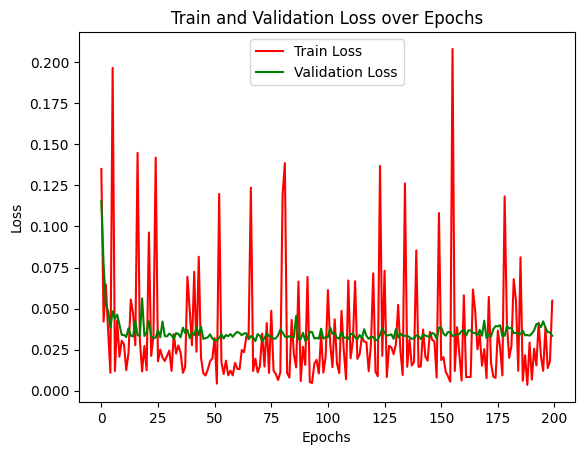

In [179]:
#实际误差是61。8*0.1017=6.69
#01062,0.1020
plt.figure()
mse_values = [d['MSE'] for d in valid_losses]
plt.plot(train_losses, 'r', label='Train Loss')
plt.plot(mse_values, 'g', label='Validation Loss')
plt.title('Train and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#定义一个计算R^2的函数
#TSS = ∑(yi - y_mean)²，RSS = ∑(yi - ŷi)²
#rsquared=1-rss/tss
def rsquared(y_train,y_pred):
    rss=sum((y_train-y_pred)**2)
    tss=sum((y_train-np.mean(y_train))**2)
    rsquared=1-rss/tss
    return rsquared

In [185]:
def calc_mae(model, val_loader):
    total_abs_error = 0
    total_samples = 0
    for data in val_loader.create_dict_iterator(output_numpy=True):
        inputs, targets = Tensor(data["features"]), Tensor(data["labels"])
        # 直接使用模型进行预测
        outputs = model.predict(inputs)
        abs_error = np.abs(outputs.asnumpy() - targets)
        total_abs_error += abs_error.sum()
        total_samples += inputs.shape[0]
    
    average_mae = total_abs_error / total_samples
    return average_mae

def model_predict(model, predict_data,min_mae):
    for data in predict_data.create_dict_iterator(output_numpy=True):
        features,label = Tensor(data["features"]), Tensor(data["labels"])
        predict_rate_untransformed=model(features)
        # 获取相应的均值和标准差
        label_mean = scaler_y.mean_
        label_std = scaler_y.scale_
        # 反向变换
        # 反向变换
        predict_rate= (predict_rate_untransformed.asnumpy()*label_std) + label_mean
        label_transformed = (label.asnumpy()*label_std) + label_mean
        #计算一下差值平均
        aver_error=min_mae*label_std
        R2=rsquared(label_transformed,predict_rate)
    #print(predict_rate,label_transformed)
    print('label_mean:',label_mean,'label_std:',label_std)
    print('aver_error(transformed):',aver_error)
    print('R^2:',R2)

from mindspore import load_checkpoint, load_param_into_net
#加载最好的checkpoint
best_net = Net(input_size=8, hidden_size1=150, hidden_size2=120, activation='relu')

# 加载Checkpoint文件
param_dict = load_checkpoint("best_checkpoint.ckpt")

# 将Checkpoint中的参数加载到模型中
load_param_into_net(net, param_dict)
model_predict(net,test_data,0.0967)

label_mean: [104.4928961] label_std: [61.86305437]
aver_error(transformed): [5.98215736]
R^2: [0.9679373]
